In [1]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Union, Tuple, List
from utils import ImageBatchGenerator, ManualConvLayer

### now we will implement generic pooling class, inheriting from which, we can create AvgPool, MaxPool & MinPool 

In [34]:
class Pooling:
    def __init__(self,method:str=None,kernel_shape:Tuple[int,int]=(3,3),stride:int=1) -> None:
        methods = {
            "average":np.mean,
            "max":np.max,
            "min":np.min
        }
        self.method = methods.get(method,np.max)
        self.kernel_shape = kernel_shape
        self.stride = stride

    def forward(self, img_batch:np.ndarray) -> np.ndarray:
        self.img_x, self.img_y, self.img_channels, self.batch_size = img_batch.shape
        print("batch_size",self.batch_size)
        print("img_channels",self.img_channels)
        self.inputs = img_batch
        self.output_x = (self.img_x - self.kernel_shape[0]) // self.stride + 1
        self.output_y = (self.img_y - self.kernel_shape[1]) // self.stride + 1
        self.output = np.zeros((self.output_x, self.output_y, self.img_channels, self.batch_size)) # no need for kernel count since pooling is done per channel
        # and not added over channels
        padded_image = img_batch
        self.mask = padded_image.copy()

        for i in range(self.batch_size):

            current_padded_img = padded_image[:, :, :, i]
            for c in range(self.img_channels):
                for y in range(self.output_y):
                    for x in range(self.output_x):
                        x_start = x * self.stride
                        x_end = x_start + self.kernel_shape[0]
                        y_start = y*self.stride
                        y_end = y_start + self.kernel_shape[1]
                        current_window = current_padded_img[x_start:x_end, y_start:y_end, c]
                        val = float(self.method(current_window))
                        self.output[x, y, c, i] = val

                        # then we have to keep track of the indices that contributed to the max value
                        # for backpropagation
                        indices = np.where(current_window == val)
                        self.mask[x_start + indices[0], y_start + indices[1], c, i] = 1
           
            print(f"FINISHED element {i}/{self.batch_size}")

        return self.output
                        

In [2]:
dogs_path = r"C:\Users\ayhan\Desktop\ml-collection\data\ten_animals\raw-img\dog"
cats_path = r"C:\Users\ayhan\Desktop\ml-collection\data\ten_animals\raw-img\cat"
img_batch = ImageBatchGenerator({"dog":dogs_path, "cat":cats_path},batch_size=8,network_input_size=(50,50))
conv_layer = ManualConvLayer(kernel_shape=(3,3),kernel_count=5,padding=2)
output = conv_layer.forward(img_batch.batch_matrix)
output.shape 

(52, 52, 5, 8)

Text(0.5, 1.0, 'Input Image2')

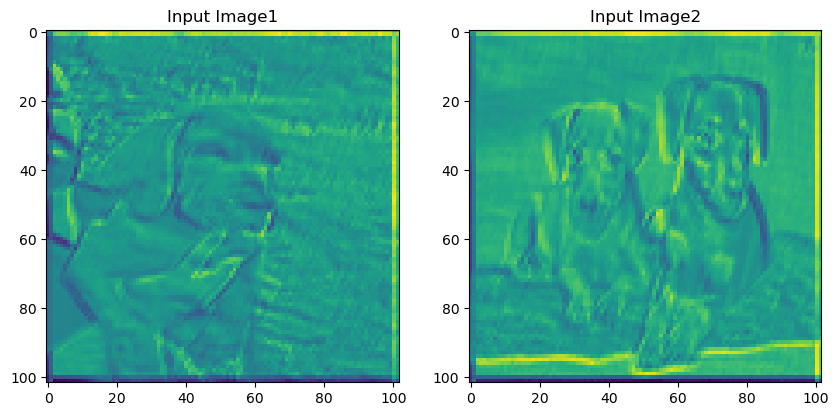

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(output[:,:,0,3])
axes[0].set_title("Input Image1")
axes[1].imshow(output[:,:,0,4])
axes[1].set_title("Input Image2")
plt.show()

### now lets visualize the mask

batch_size 2
img_channels 5


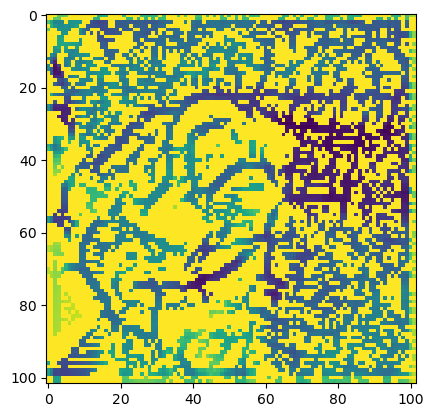

DONE WITH ONE IMAGE ITERATION


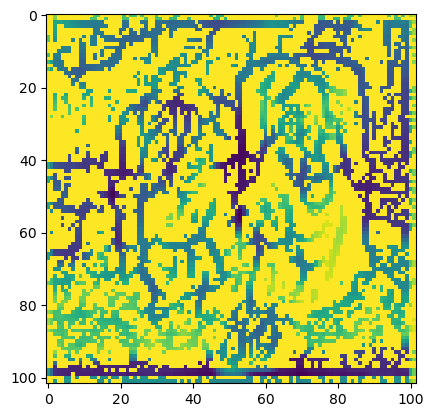

DONE WITH ONE IMAGE ITERATION


In [35]:
max_pool_layer = Pooling(method="max",kernel_shape=(3,3))
output3 = max_pool_layer.forward(output[:,:,:,3:5])


batch_size 2
img_channels 5
DONE WITH ONE IMAGE ITERATION
DONE WITH ONE IMAGE ITERATION


Text(0.5, 1.0, 'pooled img2')

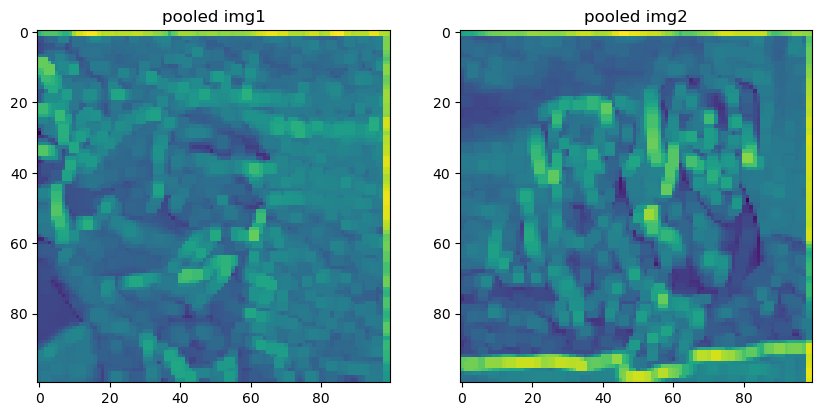

In [12]:
max_pool_layer = Pooling(method="max",kernel_shape=(3,3))
output3 = max_pool_layer.forward(output[:,:,:,3:5])
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(output3[:,:,0,0])
axes[0].set_title("pooled img1")

axes[1].imshow(output3[:,:,0,1])
axes[1].set_title("pooled img2")
plt.show()

batch_size 2
img_channels 5
DONE WITH ONE IMAGE ITERATION
DONE WITH ONE IMAGE ITERATION


Text(0.5, 1.0, 'pooled img2')

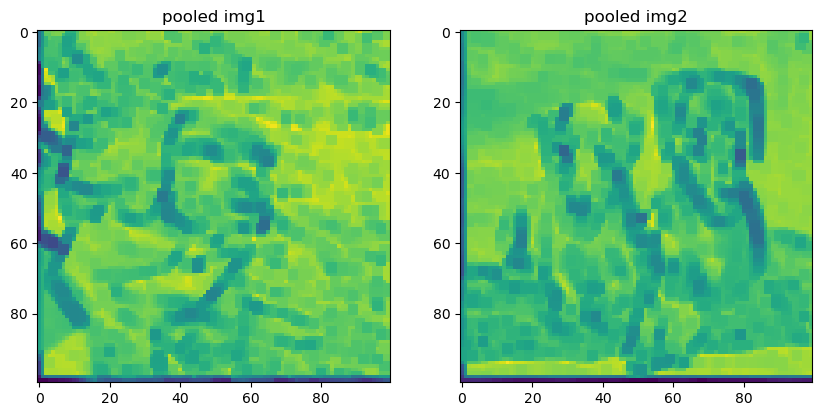

In [13]:
min_pool_layer = Pooling(method="min",kernel_shape=(3,3))
output4 = min_pool_layer.forward(output[:,:,:,3:5])
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(output4[:,:,0,0])
axes[0].set_title("pooled img1")
axes[1].imshow(output4[:,:,0,1])
axes[1].set_title("pooled img2") 
plt.show()

### now lets implement the flattening layer

In [203]:
# flattening layer will , for each image in the batch, flatten the image into a 1D array
# of L = W * H * C length, where C is the number of channels : features to our fully connected layer

class Flatten:
    def forward(self, img_batch:np.ndarray) -> np.ndarray:
        self.batch_size = img_batch.shape[0]
        self.inputs = img_batch
        self.output = img_batch.reshape(self.batch_size,-1 )
        # this requires the batch_size dim to be the first dimension
        # so there is a difference between this and the following implementation!
        # tells the numpy to infer required dimension
        # for the first dimension so that there are to be flattened batch_sized rows. 
        return self.output
    
class Flatten2: # this is way explicit implementation but doesnt utilize vectorization
    def forward(self, img_batch:np.ndarray) -> np.ndarray:
        self.img_x, self.img_y, self.img_channels,self.batch_size = img_batch.shape
        self.inputs = img_batch
        L = self.img_x * self.img_y * self.img_channels
        self.output = np.zeros((self.batch_size, L))
        for i in range(self.batch_size):
            self.output[i,:] = img_batch[:, :, :,i].reshape((1,L)) # or flatten()
        return self.output

In [207]:
output_modified = output.transpose(3,0,1,2) # to make the batch_size the first dimension
flatten1 = Flatten()
output5 = flatten1.forward(output_modified)
print(output5.shape)
print("-------------")
flatten2 = Flatten2()
output6 = flatten2.forward(output)
print(output6.shape)

(8, 13520)
-------------
(8, 13520)


In [208]:
output5, output6

(array([[  7.16010267,  18.46333677,  -4.58021035, ...,   8.42757352,
         -21.90662673,  77.19738966],
        [ 36.17282608,  66.11521552,  -9.92233341, ...,  32.4351928 ,
         -63.15604793, 243.8751495 ],
        [ 10.53367516,  24.0042529 ,  -5.20138745, ...,  20.11687287,
         -41.9909519 , 158.35271814],
        ...,
        [ -0.62978289,   5.66885769,  -3.14585596, ...,  20.11687287,
         -41.9909519 , 158.35271814],
        [ 13.10985779,  28.23549795,  -5.67574087, ...,  17.70562726,
         -37.84799693, 141.61215711],
        [  1.21034755,   8.69117558,  -3.48467983, ...,   8.21789999,
         -21.54636977,  75.7416887 ]]),
 array([[  7.16010267,  18.46333677,  -4.58021035, ...,   8.42757352,
         -21.90662673,  77.19738966],
        [ 36.17282608,  66.11521552,  -9.92233341, ...,  32.4351928 ,
         -63.15604793, 243.8751495 ],
        [ 10.53367516,  24.0042529 ,  -5.20138745, ...,  20.11687287,
         -41.9909519 , 158.35271814],
        ...,
